In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/SQL outputs/RQ3.csv")
df

,MOVIEID,TITLE,YEAR,ADULT_FLAG,IMDBRATINGS,GROSS
0,tt2543164,Arrival,2016,Non-Adult,7.9,203388186
1,tt2567026,Alice Through the Looking Glass,2016,Non-Adult,6.2,299457024
2,tt2582782,Hell or High Water,2016,Adult,7.6,37879877
3,tt2652118,"Crouching Tiger, Hidden Dragon: Sword of Destiny",2016,Non-Adult,6.1,38659039
4,tt2660888,Star Trek Beyond,2016,Non-Adult,7.0,343471816
...,...,...,...,...,...,...
199,tt2226597,The Mountain Between Us,2017,Non-Adult,6.4,62832209
200,tt2277860,Finding Dory,2016,Non-Adult,7.2,1028570889
201,tt2380307,Coco,2017,Non-Adult,8.4,807816196
202,tt2395427,Avengers: Age of Ultron,2015,Non-Adult,7.3,1402805868


In [3]:
df["Log_Gross"] = np.log10(df["GROSS"])

df["isAdult"] = (df["ADULT_FLAG"] == "Adult").astype(int)

df.head()

,MOVIEID,TITLE,YEAR,ADULT_FLAG,IMDBRATINGS,GROSS,Log_Gross,isAdult
0,tt2543164,Arrival,2016,Non-Adult,7.9,203388186,8.308326,0
1,tt2567026,Alice Through the Looking Glass,2016,Non-Adult,6.2,299457024,8.476335,0
2,tt2582782,Hell or High Water,2016,Adult,7.6,37879877,7.578409,1
3,tt2652118,"Crouching Tiger, Hidden Dragon: Sword of Destiny",2016,Non-Adult,6.1,38659039,7.587251,0
4,tt2660888,Star Trek Beyond,2016,Non-Adult,7.0,343471816,8.535891,0


Model without Interaction term

In [4]:
# Features (independent variables)
X = df[["isAdult", "IMDBRATINGS"]]

# Target (dependent variable)
y = df["Log_Gross"]

In [5]:
# Add intercept
X = sm.add_constant(X)

# Fit model
model = sm.OLS(y, X).fit()

# Summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Log_Gross   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.211
Method:                 Least Squares   F-statistic:                     28.18
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           1.62e-11
Time:                        11:57:29   Log-Likelihood:                -148.01
No. Observations:                 204   AIC:                             302.0
Df Residuals:                     201   BIC:                             312.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           6.5190      0.247     26.425      

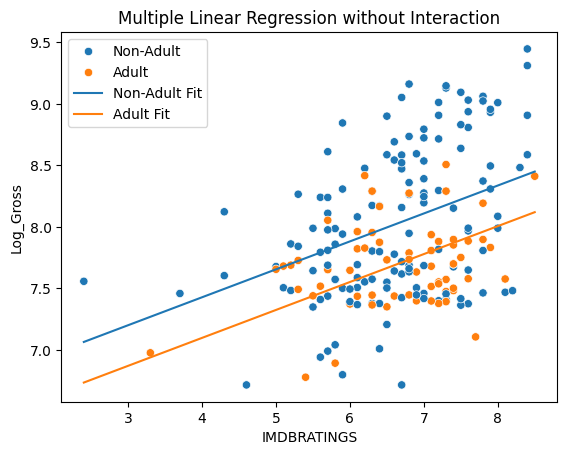

In [6]:
sns.scatterplot(x="IMDBRATINGS", y="Log_Gross", hue="ADULT_FLAG", data=df)

# Extract coefficients
b0 = model.params['const']
b1 = model.params['isAdult']
b2 = model.params['IMDBRATINGS']

# Create x values
x_vals = np.linspace(df["IMDBRATINGS"].min(), df["IMDBRATINGS"].max(), 100)

# Line for non-adult (isAdult = 0)
y_non_adult = b0 + b2 * x_vals

# Line for adult (isAdult = 1)
y_adult = (b0 + b1) + b2 * x_vals

# Plot lines
plt.plot(x_vals, y_non_adult, label="Non-Adult Fit")
plt.plot(x_vals, y_adult, label="Adult Fit")

plt.xlabel("IMDBRATINGS")
plt.ylabel("Log_Gross")
plt.title("Multiple Linear Regression without Interaction")
plt.legend()

plt.show()


Model with Interaction term

In [7]:
df["interaction"] = df["isAdult"] * df["IMDBRATINGS"]

X = df[["isAdult", "IMDBRATINGS", "interaction"]]
X = sm.add_constant(X)

model_inter = sm.OLS(y, X).fit()

print(model_inter.summary())

                            OLS Regression Results                            
Dep. Variable:              Log_Gross   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.221
Method:                 Least Squares   F-statistic:                     20.22
Date:                Sat, 04 Apr 2026   Prob (F-statistic):           1.73e-11
Time:                        11:57:29   Log-Likelihood:                -146.20
No. Observations:                 204   AIC:                             300.4
Df Residuals:                     200   BIC:                             313.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           6.2313      0.288     21.600      

After controlling for IMDb ratings, adult content has a statistically significant negative effect on international box office revenue. The coefficient on isAdult is −0.3302 (p < 0.001), indicating that, on average, adult films earn substantially less than non-adult films with similar ratings. 

In contrast, higher IMDb ratings are associated with increased revenue. 

Overall, this result supports the conclusion that adult content negatively impacts box office performance even after accounting for film quality as measured by ratings.

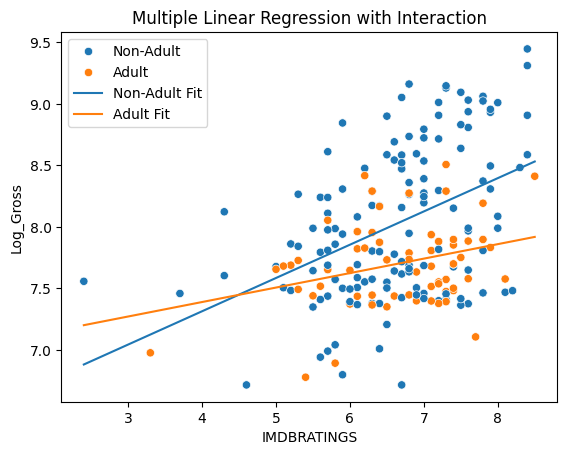

In [9]:
sns.scatterplot(x="IMDBRATINGS", y="Log_Gross", hue="ADULT_FLAG", data=df)

# Extract coefficients
b0 = model_inter.params['const']
b1 = model_inter.params['isAdult']
b2 = model_inter.params['IMDBRATINGS']
b3 = model_inter.params['interaction']

x_vals = np.linspace(df["IMDBRATINGS"].min(), df["IMDBRATINGS"].max(), 100)

# Non-adult
y_non = b0 + b2 * x_vals

# Adult
y_adult = (b0 + b1) + (b2 + b3) * x_vals

plt.plot(x_vals, y_non, label="Non-Adult Fit")
plt.plot(x_vals, y_adult, label="Adult Fit")
plt.title("Multiple Linear Regression with Interaction")
plt.legend()
plt.show()

After including an interaction between isAdult and IMDb ratings, the direct effect of adult content is no longer statistically significant (p = 0.207). However, the interaction term is negative (−0.1529) and marginally significant (p = 0.060), suggesting that the positive effect of IMDb ratings on revenue is weaker for adult films compared to non-adult films. In other words, while higher ratings generally increase revenue, this benefit is smaller for adult films. Overall, there is some evidence that adult content moderates the relationship between ratings and revenue, though the effect is only weakly significant.